# W1-D1 Assignment: Metric Anomaly Detection
## Phase 1: EDA & Hiểu Data

In [ ]:
# Install required packages
%pip install pandas numpy matplotlib scipy statsmodels scikit-learn joblib

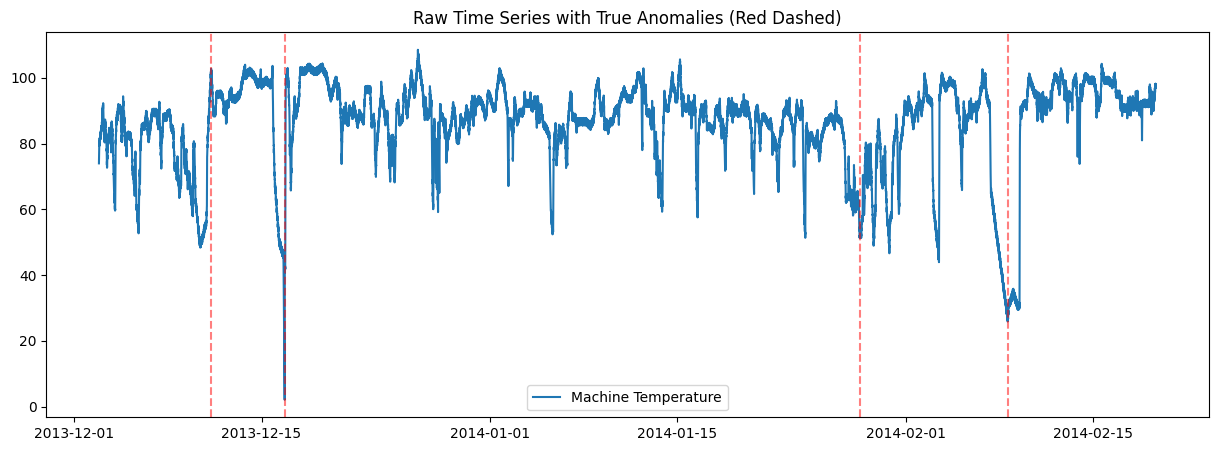

Mean: 85.93, Std: 13.75
Skewness: -1.83
Min: 2.08, Max: 108.51


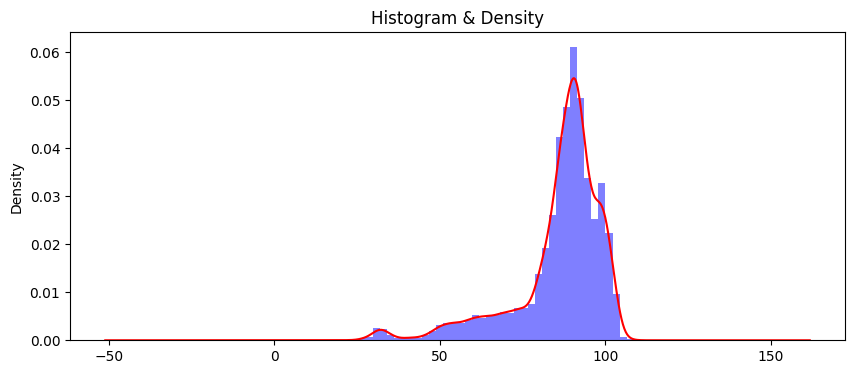

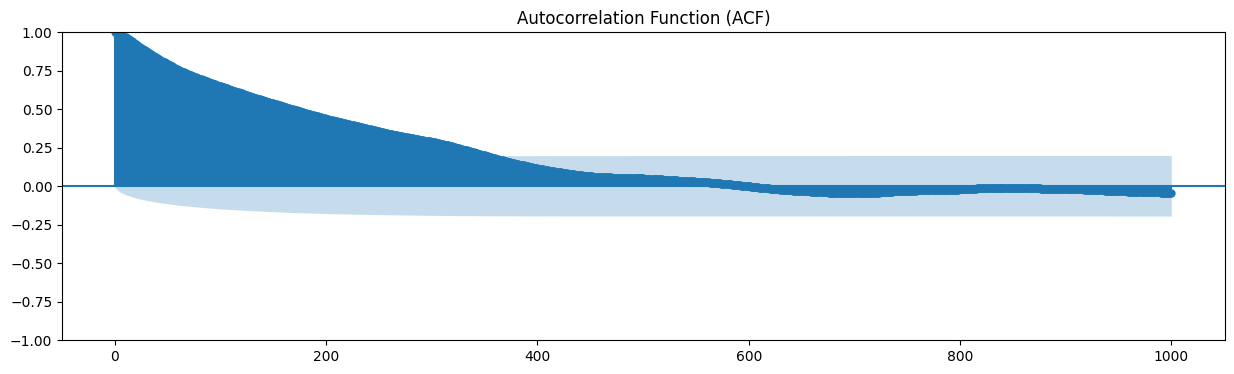

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf

# 1. Load data
df = pd.read_csv('machine_temperature_system_failure.csv', parse_dates=['timestamp'])
df.set_index('timestamp', inplace=True)

# Lấy nhãn ground truth
with open('combined_labels.json', 'r') as f:
    labels = json.load(f)
anomaly_timestamps = labels.get('realKnownCause/machine_temperature_system_failure.csv', [])
anomaly_timestamps = pd.to_datetime(anomaly_timestamps)

# 2. Plot raw time series
plt.figure(figsize=(15, 5))
plt.plot(df.index, df['value'], label='Machine Temperature')
for ts in anomaly_timestamps:
    plt.axvline(x=ts, color='red', alpha=0.5, linestyle='--')
plt.title('Raw Time Series with True Anomalies (Red Dashed)')
plt.legend()
plt.show()

# 3. Tính basic stats
print(f"Mean: {df['value'].mean():.2f}, Std: {df['value'].std():.2f}")
print(f"Skewness: {stats.skew(df['value']):.2f}")
print(f"Min: {df['value'].min():.2f}, Max: {df['value'].max():.2f}")

# 4. Plot histogram & density
plt.figure(figsize=(10, 4))
df['value'].plot(kind='hist', bins=50, density=True, alpha=0.5, color='blue')
df['value'].plot(kind='kde', color='red')
plt.title('Histogram & Density')
plt.show()

# 5. Plot ACF
fig, ax = plt.subplots(figsize=(15, 4))
plot_acf(df['value'], lags=1000, ax=ax)
plt.title('Autocorrelation Function (ACF)')
plt.show()

## Phase 2 & 3: Implement 2 Detectors & So Sánh
Detector 1: Rolling Z-Score (3-Sigma)
Detector 2: Isolation Forest

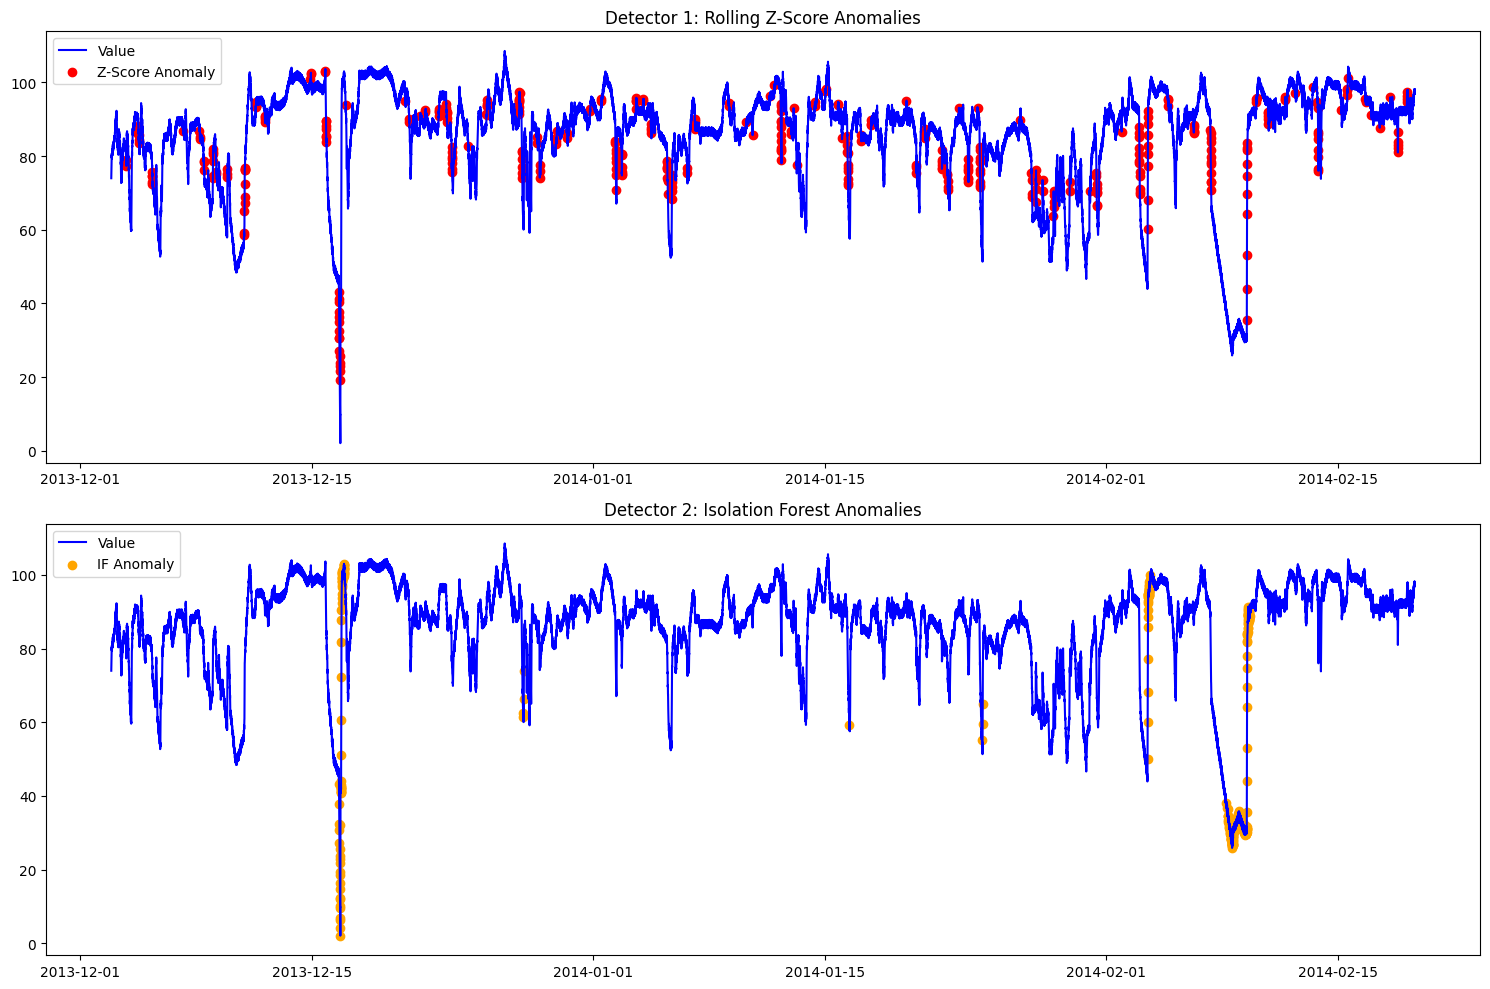

In [7]:
from sklearn.ensemble import IsolationForest
import joblib

# ----- DETECTOR 1: Rolling Z-Score -----
window_size = 60
threshold_z = 3.0

# Tránh nhiễu ở những phút đầu tiên bằng cách yêu cầu ít nhất nửa window
rolling_mean = df['value'].rolling(window=window_size, min_periods=window_size//2).mean()
rolling_std = df['value'].rolling(window=window_size, min_periods=window_size//2).std().replace(0, 1e-10)
z_scores = (df['value'] - rolling_mean) / rolling_std
df['zscore_anomaly'] = np.abs(z_scores) > threshold_z
df['zscore_anomaly'] = df['zscore_anomaly'].fillna(False) # Chuyển các vùng bị NaN do chưa đủ data thành False

# ----- DETECTOR 2: Isolation Forest -----
# Tạo feature table
features = pd.DataFrame({
    'value': df['value'],
    'rolling_mean': rolling_mean,
    'rolling_std': rolling_std,
    'rate_of_change': df['value'].diff()
})

# Dùng boolean mask để tránh lỗi duplicate index
valid_mask = features.notna().all(axis=1)
valid_features = features[valid_mask]

iso_forest = IsolationForest(n_estimators=200, contamination=0.02, random_state=42)
iso_forest.fit(valid_features)

# Khôi phục lại df ban đầu
df['if_anomaly'] = False
df.loc[valid_mask, 'if_anomaly'] = iso_forest.predict(valid_features) == -1

# Save Model
joblib.dump(iso_forest, 'isolation_forest_model.pkl')

# ----- PLOT KẾT QUẢ -----
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

# Plot Z-Score
ax1.plot(df.index, df['value'], label='Value', color='blue')
ax1.scatter(df[df['zscore_anomaly']].index, df[df['zscore_anomaly']]['value'], color='red', label='Z-Score Anomaly')
ax1.set_title('Detector 1: Rolling Z-Score Anomalies')
ax1.legend()

# Plot IF
ax2.plot(df.index, df['value'], label='Value', color='blue')
ax2.scatter(df[df['if_anomaly']].index, df[df['if_anomaly']]['value'], color='orange', label='IF Anomaly')
ax2.set_title('Detector 2: Isolation Forest Anomalies')
ax2.legend()

plt.tight_layout()
plt.show()

In [11]:
# Đánh Giá chuyên nghiệp (Dùng Time Tolerance 5 phút)
def evaluate_with_tolerance(predictions, true_anomalies, index, tolerance='5min'):
    pred_times = index[predictions]
    tp = 0
    matched_true = set()
    
    for pred_time in pred_times:
        for true_time in true_anomalies:
            if abs((pred_time - true_time).total_seconds()) <= pd.Timedelta(tolerance).total_seconds():
                if true_time not in matched_true:
                    tp += 1
                    matched_true.add(true_time)
                    break
                    
    fp = len(pred_times) - tp
    fn = len(true_anomalies) - len(matched_true)
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    return precision, recall, f1, fp

print("--- Z-Score Evaluation (5min tolerance) ---")
p_z, r_z, f1_z, fp_z = evaluate_with_tolerance(df['zscore_anomaly'], anomaly_timestamps, df.index, tolerance='5min')
print(f"Precision: {p_z:.2f}, Recall: {r_z:.2f}, F1: {f1_z:.2f}, False Alarms: {fp_z}")

print("\n--- Isolation Forest Tuning (5min tolerance) ---")
# Thử nghiệm với các mức contamination khác nhau
for cont in [0.01, 0.02, 0.05]:
    iso = IsolationForest(n_estimators=200, contamination=cont, random_state=42)
    iso.fit(valid_features)
    preds = iso.predict(valid_features) == -1
    
    # Tạo series tạm thời để đánh giá
    temp_preds = pd.Series(False, index=df.index)
    temp_preds.loc[valid_mask] = preds
    
    p, r, f1, fp = evaluate_with_tolerance(temp_preds, anomaly_timestamps, df.index, tolerance='5min')
    print(f"Contamination = {cont} -> Precision: {p:.2f}, Recall: {r:.2f}, F1: {f1:.2f}, False Alarms: {fp}")


--- Z-Score Evaluation (5min tolerance) ---
Precision: 0.00, Recall: 0.00, F1: 0.00, False Alarms: 395

--- Isolation Forest Tuning (5min tolerance) ---
Contamination = 0.01 -> Precision: 0.01, Recall: 0.50, F1: 0.02, False Alarms: 225
Contamination = 0.02 -> Precision: 0.00, Recall: 0.50, F1: 0.01, False Alarms: 452
Contamination = 0.05 -> Precision: 0.00, Recall: 0.50, F1: 0.00, False Alarms: 1132
